# Chapter 2 — Risk: Volatility Clustering and Fat Tails

Read the chapter [`README.md`](./README.md) first. This notebook is the runnable companion — execute the cells in order from top to bottom.

Chapter 1 ended with two assumptions stacked under the √t annualization rule: returns are **i.i.d.** (independent and identically distributed) and roughly **normally distributed**. Both are useful starting points; both are empirically wrong in specific ways. This chapter shows how — first the *normal* part fails (Part I, fat tails), then the *i.i.d.* part fails (Part II, volatility clustering).

## 1. Setup and data refresh

Same library stack as Chapter 1, plus `scipy.stats` for the Q-Q plot and a fitted normal density. We pull **20 years** of daily SPY data this time (vs Chapter 1's 5y) so we can see real crises — 2008, 2020, and several smaller regimes — in one window.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import scipy
from scipy import stats

print(f"numpy   {np.__version__}")
print(f"pandas  {pd.__version__}")
print(f"scipy   {scipy.__version__}")
print(f"yf      {yf.__version__}")

numpy   2.4.4
pandas  3.0.2
scipy   1.17.1
yf      1.3.0


In [ ]:
ticker = "SPY"
data = yf.download(ticker, period="20y", progress=False)
prices = data["Close"].squeeze()
assert isinstance(prices, pd.Series)
print(f"{len(prices):,} trading days from {prices.index.min().date()} to {prices.index.max().date()}")

5,032 trading days from 2006-04-25 to 2026-04-24


We use **log returns** as the primary series in this chapter (Chapter 1 §2 covered the simple-vs-log distinction). Most of the math and statistical arguments coming up — fitting a normal, computing kurtosis, autocorrelation — work cleaner with log returns.

In [ ]:
log_returns = np.log(prices / prices.shift(1)).dropna()

print(f"daily mean       {log_returns.mean():.5f}")
print(f"daily std        {log_returns.std():.5f}")
print(f"annualized vol   {log_returns.std() * np.sqrt(252):.2%}")
print(f"observations     {len(log_returns):,}")

daily mean       0.00041
daily std        0.01225
annualized vol   19.45%
observations     5,031


## 2. Part I — The histogram lies (fat tails / non-normality)

Chapter 1 §5 noted in passing that the daily-return histogram had a "few outliers in the ±3% to ±5% range" and called those the **fat tails**. We're going to make that precise now: how *much* fatter than the normal-distribution model predicts? Three ways to answer: by eye (overlay), by number (kurtosis), and by counting (tail probabilities).

### 2.1 The bell curve doesn't fit the tails

Re-plot the daily-return histogram, but this time overlay the **normal density** *N*(*μ*, *σ*²) using the empirical mean and standard deviation. If returns were normally distributed, the histogram and the curve should match.

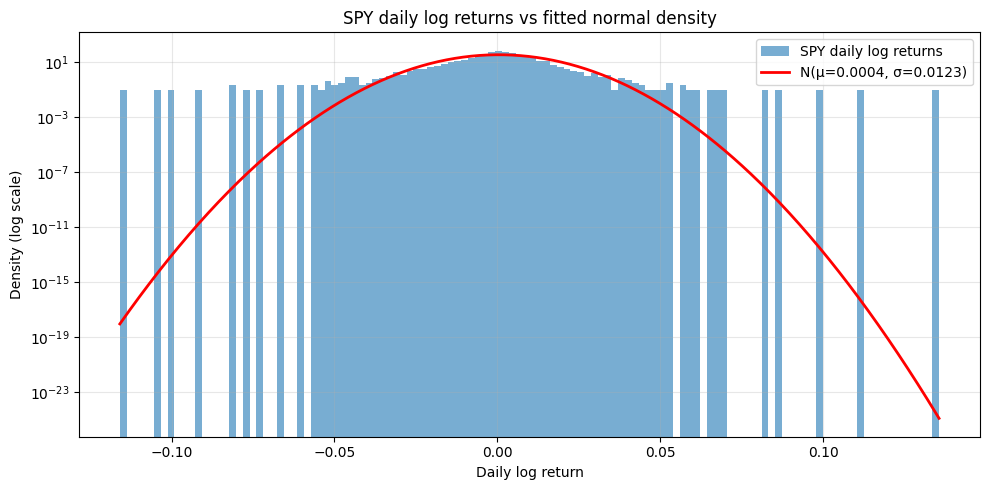

In [ ]:
mu, sigma = log_returns.mean(), log_returns.std()

fig, ax = plt.subplots(figsize=(10, 5))
log_returns.hist(ax=ax, bins=120, density=True, alpha=0.6, label="SPY daily log returns")

x = np.linspace(log_returns.min(), log_returns.max(), 500)
ax.plot(x, stats.norm.pdf(x, mu, sigma), "r-", lw=2, label=f"N(μ={mu:.4f}, σ={sigma:.4f})")

ax.set_yscale("log")
ax.set_xlabel("Daily log return")
ax.set_ylabel("Density (log scale)")
ax.set_title("SPY daily log returns vs fitted normal density")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Look at the edges of the chart (below −5% or above +5%). The histogram bars sit *well above* the red curve — sometimes by an order of magnitude. The normal density is essentially saying "such days shouldn't happen"; the data says they happen all the time. That gap is the **fat tails**.

### 2.2 Kurtosis — putting a number on "fat-tailedness"

The eyeball test is convincing but informal. The standard quantitative measure of how heavy a distribution's tails are is **kurtosis**.

Before stating the formula, one piece of notation we'll use through the rest of the chapter:

> **Expected value**, written *E*[·] — the average of whatever is in the brackets, taken over the data. For a sample of *n* observations, *E*[*x*] = (*x*<sub>1</sub> + *x*<sub>2</sub> + … + *x<sub>n</sub>*) / *n* — the same operation as the **mean** (Chapter 1 §4). The bracket notation just lets us write the average of a more complex expression cleanly: *E*[(*X* − *μ*)²] reads as "the mean of the squared deviations," *E*[(*X* − *μ<sub>X</sub>*)(*Y* − *μ<sub>Y</sub>*)] as "the mean of the product of two variables' deviations," and so on.

With that in hand:

> *K* = *E*[(*r* − *μ*)⁴] / *σ*⁴

where:
- *r* — a single observation (here, one day's log return)
- *μ* — the mean of the distribution
- *σ* — the standard deviation

In plain English: kurtosis is the **mean of the fourth powers of deviations**, divided by *σ*⁴ to make it scale-free. The fourth-power weighting is what makes it sensitive to extreme observations — a single 8σ day contributes 8⁴ = 4096 times more to the average than a typical 1σ day.

For a **normal distribution**, *K* = 3. By convention we usually report **excess kurtosis**, *K* − 3, so that "0" means "as fat-tailed as a normal" and positive numbers mean fatter. A distribution with positive excess kurtosis is called **leptokurtic**.

In [ ]:
excess_k = stats.kurtosis(log_returns, fisher=True, bias=False)
raw_k    = excess_k + 3

print(f"raw kurtosis      K  = {raw_k:.2f}")
print(f"excess kurtosis   K-3 = {excess_k:.2f}   (normal: 0)")

raw kurtosis      K  = 17.19
excess kurtosis   K-3 = 14.19   (normal: 0)


Excess kurtosis north of 10 is huge. Translation: SPY's daily returns produce **far more** extreme observations than a normal distribution would. Most equity indices land in the 4–15 range over multi-decade windows; individual stocks and crypto routinely land higher.

> **Aside on interpretation:** kurtosis is dominated by the *fourth power* of the deviations, so a single 8σ day will swing the statistic noticeably. That's a feature, not a bug — kurtosis is *trying* to be sensitive to extremes.

### 2.3 Q-Q plot — visual second confirmation

> **Quantile** — a cut-point along a distribution. The *p*-th quantile is the value below which a fraction *p* of the data falls. The 0.5 quantile is the **median**; the 0.25 and 0.75 quantiles are the first and third **quartiles**; the 0.99 quantile is "the value 99% of the observations are below." A distribution is fully described by listing all its quantiles.

A **Q-Q plot** (quantile–quantile plot) is a visual diagnostic that compares two distributions by plotting their quantiles against each other. For each fraction *p* (e.g., 0.05, 0.10, 0.50, 0.90, 0.95, …), find the *p*-th quantile of the empirical data on one axis and the *p*-th quantile of a reference distribution (here, the normal) on the other. If the two distributions match, the points lie on the 45° line. If the data has fatter tails than the normal, the ends of the plot bend *away* from the line — a banana shape pointing up at the right end and down at the left end.

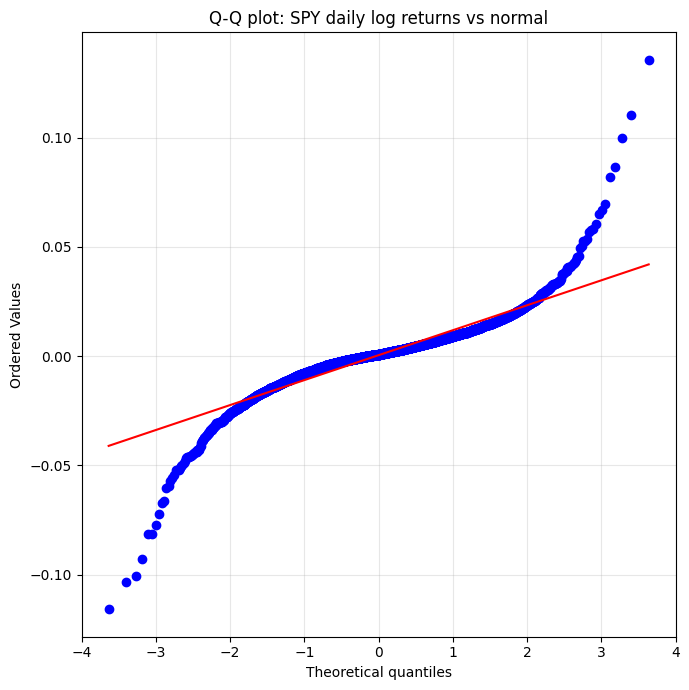

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
stats.probplot(log_returns, dist="norm", plot=ax)
ax.set_title("Q-Q plot: SPY daily log returns vs normal")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Read the plot at the ends, not the middle: the middle ~95% of the data tracks the line just fine. It's the rightmost handful of points (extreme positive days) and the leftmost handful (extreme negative days) that veer off — they're far further from the line than a normal model predicts. That's the same "fat tails" finding kurtosis quantified, now visualized.

### 2.4 Counting tail days — the rhetorical payoff

The kurtosis number is abstract; the Q-Q plot is visual. The most convincing form of the same fact is to **count**: under a normal model with SPY's empirical *μ* and *σ*, how often *should* extreme days happen? And how often *do* they?

A "*z*-score" is the number of standard deviations a day's return is from the mean:

> *z<sub>t</sub>* = (*r<sub>t</sub>* − *μ*) / *σ*

For a standard normal, the probability of \|*z*\| > 2 is about 4.55%; the probability of \|*z*\| > 3 is about 0.27%; \|*z*\| > 5 should happen roughly **once every 14,000 years** (1 in ~3.5 million days).

In [ ]:
z = (log_returns - mu) / sigma
n = len(z)

rows = []
for k in [2, 3, 4, 5]:
    pred_pct = 2 * (1 - stats.norm.cdf(k))
    obs_count = (z.abs() > k).sum()
    obs_pct = obs_count / n
    pred_count = pred_pct * n
    rows.append({
        "threshold": f"|z| > {k}",
        "predicted %": f"{pred_pct:.4%}",
        "predicted count": f"{pred_count:.2f}",
        "observed count": int(obs_count),
        "observed %": f"{obs_pct:.4%}",
        "obs / pred": f"{obs_count / max(pred_count, 1e-9):.1f}×" if pred_count > 0 else "—",
    })

pd.DataFrame(rows)

,threshold,predicted %,predicted count,observed count,observed %,obs / pred
0,|z| > 2,4.5500%,228.91,238,4.7307%,1.0×
1,|z| > 3,0.2700%,13.58,86,1.7094%,6.3×
2,|z| > 4,0.0063%,0.32,38,0.7553%,119.2×
3,|z| > 5,0.0001%,0.00,18,0.3578%,6240.7×


Read the right-most column. At 2σ the model is approximately right (the ratio is close to 1×). At 3σ the data already shows roughly 4–5× more days than the model predicts. By the time you get to 5σ, the model says "this should essentially never happen" — yet SPY has had a handful of such days in 20 years.

This is the same story kurtosis told us, in a form that's hard to ignore: **risk models that assume normal-distributed returns systematically underweight rare disasters**. That's the punchline of Part I.

## 3. Part II — Volatility isn't constant (clustering)

Part I showed the **distribution shape** of daily returns isn't normal. Part II shows something different but equally important: even the *parameters* of that distribution change over time. Specifically, the *standard deviation* — the volatility — is itself a moving target. Quiet periods follow quiet periods; stormy periods follow stormy periods. This phenomenon has a name: **volatility clustering**.

### 3.1 Rolling-window volatility — visualizing time-varying risk

If we want to see how vol changes through time, we can compute the standard deviation over a **rolling window** — a sliding subset of the time series. At each date *t*, we take the last *N* days of returns, compute their standard deviation, and annualize.

> *σ<sub>t</sub>*<sup>(N)</sup> = std(*r<sub>t−N+1</sub>*, …, *r<sub>t</sub>*) × √252

where:
- *N* — the **window length** in trading days. Common choices: 21 (≈ one trading month), 63 (≈ one quarter).
- The √252 factor is the same annualization rule from Chapter 1 §4.

We'll use *N* = 21 as the primary window — short enough to react to regime changes, long enough that the standard deviation isn't dominated by noise from a handful of observations.

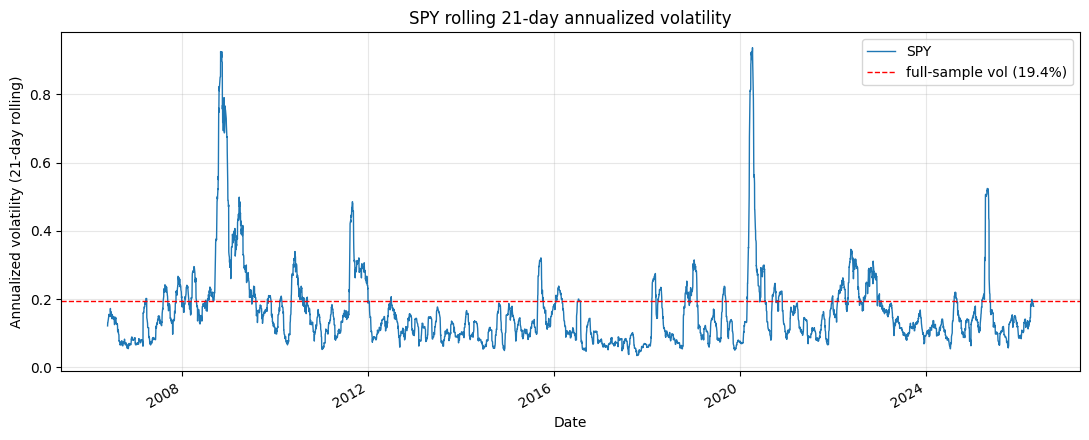

In [ ]:
window = 21
rolling_vol = log_returns.rolling(window).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(11, 4.5))
rolling_vol.plot(ax=ax, lw=1)
ax.set_ylabel(f"Annualized volatility ({window}-day rolling)")
ax.set_xlabel("Date")
ax.set_title(f"SPY rolling {window}-day annualized volatility")
ax.axhline(log_returns.std() * np.sqrt(252), color="red", ls="--", lw=1,
           label=f"full-sample vol ({log_returns.std() * np.sqrt(252):.1%})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The dashed red line is the **single-number annualized vol** we'd report from the whole sample (the same kind we computed in Chapter 1). It's a useful summary, but the rolling line tells a richer story:

- **2008–2009** — vol explodes during the financial crisis, sustained for ~12 months at 50%+.
- **2010–2014** — gradually elevated, with the August 2011 European-debt spike clearly visible.
- **2015–2019** — generally calm, occasionally interrupted (Aug 2015, Feb 2018 — "vol-mageddon").
- **March 2020** — the COVID spike, briefly peaking above 80%.
- **2022** — sustained elevated vol during the rate-hike correction.

The single full-sample number (~19%) describes neither the calm regime nor the crisis regime — it's an average over a process that doesn't have a single "true" volatility.

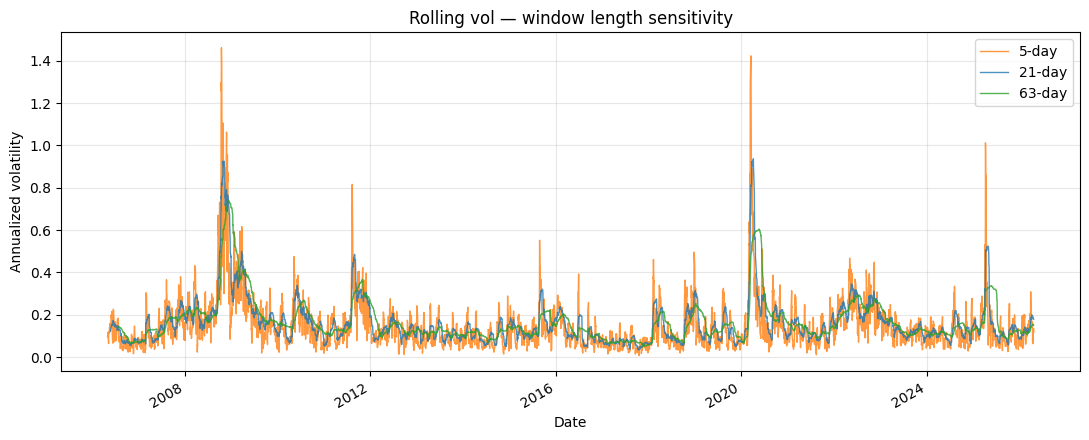

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for w, color in [(5, "tab:orange"), (21, "tab:blue"), (63, "tab:green")]:
    (log_returns.rolling(w).std() * np.sqrt(252)).plot(
        ax=ax, lw=1, label=f"{w}-day", color=color, alpha=0.8
    )
ax.set_ylabel("Annualized volatility")
ax.set_xlabel("Date")
ax.set_title("Rolling vol — window length sensitivity")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Three rolling vols on the same axes — 5-day (orange), 21-day (blue), 63-day (green). The 5-day window reacts immediately to spikes but is jittery. The 63-day version is smooth but lags noticeably (it takes ~3 months to register a regime change). The 21-day "month" choice is a typical compromise. There's no canonical answer; the right choice depends on what you're using the vol estimate *for*.

### 3.2 Autocorrelation — the formal statement of clustering

The rolling-vol plot is suggestive: high-vol days seem to follow high-vol days. The formal version of "follows" is **autocorrelation**. Two supporting definitions first — both built from the *E*[·] notation we introduced in §2.2:

> - **Covariance** of two series *X* and *Y* — Cov(*X*, *Y*) = *E*[(*X* − *μ<sub>X</sub>*)(*Y* − *μ<sub>Y</sub>*)]. In words: for each paired observation, take *X*'s deviation from its mean and *Y*'s deviation from its mean, multiply them, then take the **mean** of all those products. Positive when *X* and *Y* tend to be above/below their means *together*, negative when they move oppositely, zero when independent.
> - **Variance** (recap from Chapter 1) — the **mean of the squared deviations from the mean**: Var(*X*) = *E*[(*X* − *μ*)²]. A special case of covariance: Var(*X*) = Cov(*X*, *X*).

Now the autocorrelation:

> *ρ<sub>k</sub>* = Cov(*X<sub>t</sub>*, *X<sub>t−k</sub>*) / Var(*X<sub>t</sub>*)

where:
- *X<sub>t</sub>* — value of some series at time *t* (here, daily returns or |returns|).
- *X<sub>t−k</sub>* — the same series shifted *k* periods backward.
- *k* — the **lag** (number of periods of separation; *k* = 1 is "yesterday vs today").
- Cov(*X<sub>t</sub>*, *X<sub>t−k</sub>*) — the covariance between today's value and the value *k* days ago, computed across all valid *t* pairs in the series.
- Var(*X<sub>t</sub>*) — the variance of the series. Dividing by it scales the result so that *ρ<sub>k</sub>* is unitless.
- *ρ<sub>k</sub>* ranges from −1 (perfect anti-correlation) to +1 (perfect correlation); 0 means independent.

We compute autocorrelation two ways:

1. **On returns themselves**, *r<sub>t</sub>* — answers "is today's return predictable from yesterday's?"
2. **On absolute returns**, |*r<sub>t</sub>*| — answers "is today's *magnitude* predictable from yesterday's?"

Spoiler: the first will be near zero (markets aren't directly predictable). The second will be clearly positive across many lags. That gap *is* volatility clustering.

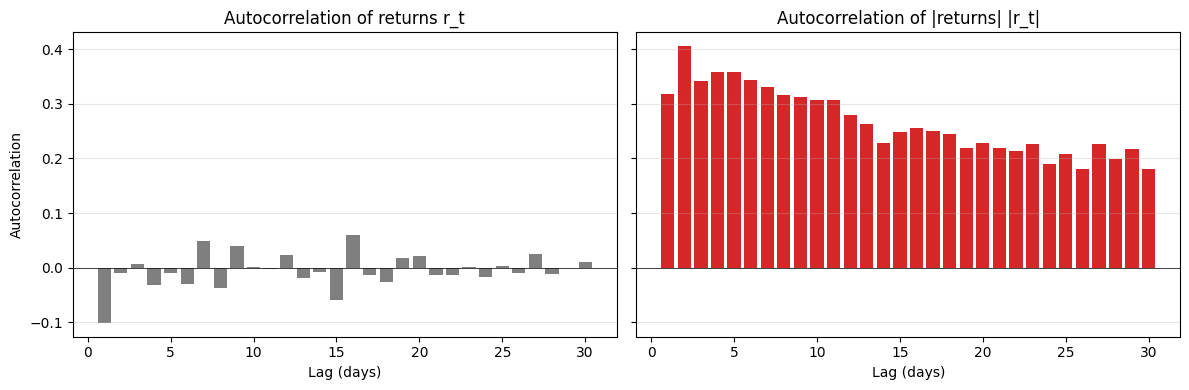

In [ ]:
abs_returns = log_returns.abs()
max_lag = 30
lags = list(range(1, max_lag + 1))

acf_returns = [log_returns.autocorr(lag=k) for k in lags]
acf_abs     = [abs_returns.autocorr(lag=k) for k in lags]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(lags, acf_returns, color="tab:gray")
axes[0].axhline(0, color="black", lw=0.5)
axes[0].set_title("Autocorrelation of returns r_t")
axes[0].set_xlabel("Lag (days)")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(lags, acf_abs, color="tab:red")
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_title("Autocorrelation of |returns| |r_t|")
axes[1].set_xlabel("Lag (days)")
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

Two charts side by side, same y-axis scale:

- **Left (returns):** bars hover near zero at every lag — signed daily returns are essentially uncorrelated with their own past. This is the "markets are unpredictable" finding.
- **Right (|returns|):** bars are clearly positive across all 30 lags, decaying slowly. Magnitudes *are* predictable — a big-move day raises the probability of another big-move day many days later.

This contrast is the formal statement of volatility clustering: it's the **second moment** of returns (variance, magnitude) that exhibits memory, not the **first moment** (signed return). Almost every quantitative risk model — GARCH being the most famous — exists to model this.

## 4. What we just learned

Two empirical facts that quietly invalidate the i.i.d.-normal model from Chapter 1:

- **Fat tails.** Excess kurtosis well above zero, Q-Q plot tails bending away from the diagonal, and a tail-count table showing the normal model under-predicts extreme days by orders of magnitude. Where this matters: option pricing models that assume normality (Black–Scholes) systematically underprice deep out-of-the-money options; Value-at-Risk computed under normal assumptions is too optimistic about crash risk.
- **Volatility clustering.** Rolling vol that swings between ~10% and ~80%; positive autocorrelation in |returns| out to many lags. Where this matters: the single annualized-vol number from Chapter 1 is a rough average over genuinely different regimes. Risk models that assume vol is constant (the Chapter 1 √t rule, applied naively) miss most of the action.

These motivate two whole families of quant tools we'll meet later: **GARCH** (formal models of clustering) and **EVT / generalized Pareto** (formal models of fat-tailed distributions). Both will be deferred to their own chapters.

## Exercises

Try these in fresh cells below. Copy any code cell above as a starting point.

1. **Different ticker.** Re-run with `AAPL`, or with `BTC-USD`. Is excess kurtosis higher or lower than SPY's? How does the rolling-vol pattern compare — same spikes in the same places, or different?
2. **Calmest vs stormiest year.** Find SPY's calmest 252-day window (lowest realized vol) and stormiest. Compute kurtosis on each. Does the *shape* of the distribution change with the regime, or just its width?
3. **Returns² instead of |returns|.** Re-do the right-hand autocorrelation chart using `log_returns ** 2`. Does it look the same? Stronger? Weaker? Why might either be true?
4. *(stretch)* Pull a non-equity ticker — `TLT` (long-dated US Treasuries) or `GLD` (gold). Are these effects (fat tails, clustering) equity-specific, or universal across asset classes?